# CPP Biological Interpretation: SP Types vs Non-SP

This notebook investigates type-specific physicochemical signatures of signal peptides by comparing each SP type against Non-SP sequences.

Unlike the SP type classifier notebook, this notebook is not designed as the main classification pipeline. Its purpose is biological interpretation: identifying which CPP-derived physicochemical features distinguish each SP type from Non-SP sequences.


## 1. Imports

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import aaanalysis as aa
import aaanalysis.utils as ut

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None


## 2. Paths and configuration

This interpretation notebook uses the parsed SignalP 6.0 dataset generated by `scripts/01_preprocess_signalp6.py`.

Each comparison uses:

- positive class: one SP type
- negative class: Non-SP sequences

The comparisons are intended to reveal type-specific biological signatures relative to Non-SP sequences, not to replace the SP type classifier pipeline.


In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "dataset_parsed.csv"

FEATURE_DIR = PROJECT_ROOT / "features"
PLOT_DIR = PROJECT_ROOT / "plots"
METRIC_DIR = PROJECT_ROOT / "results" / "metrics"
MODEL_DIR = PROJECT_ROOT / "models"

for d in [
    FEATURE_DIR / "metadata",
    PLOT_DIR,
    METRIC_DIR,
    MODEL_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

SP_TYPES = ["SP", "LIPO", "TAT", "TATLIPO", "PILIN"]

MIN_PRE_CS_LEN = 5
POST_CS_LEN = 15
PRE_CS_LEN_FOR_PLOTS = 24
TEST_SIZE = 0.20
RANDOM_STATE = 42
MAX_COR = 0.5

# Type-vs-Non-SP interpretation uses controlled Non-SP subsampling.
# Rare types need enough Non-SP diversity, but too many negatives can dominate CPP feature selection.
TYPE_NONSP_RATIOS = {
    "SP": 2,
    "LIPO": 3,
    "TAT": 5,
    "TATLIPO": 10,
    "PILIN": 10,
}


## 3. Load parsed dataset

In [3]:
df = pd.read_csv(DATA_PATH)

required = [
    "entry", "kingdom", "sp_type", "sequence", "annotation",
    "label_binary", "cs_position", "pre_cs", "post_cs",
    "pre_cs_len", "post_cs_len",
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Apply the same minimum pre-CS length used in the clean pipeline.
df = df[df["pre_cs_len"] >= MIN_PRE_CS_LEN].copy().reset_index(drop=True)

print(df.shape)
print(df["label_binary"].value_counts())
print(df["sp_type"].value_counts())


(20287, 12)
label_binary
0    15625
1     4662
Name: count, dtype: int64
sp_type
NO_SP      15625
SP          2582
LIPO        1615
TAT          365
PILIN         67
TATLIPO       33
Name: count, dtype: int64


## 4. CPP setup

The cleaned dataset uses `pre_cs` and `post_cs`, while AAanalysis CPP internally expects part names such as `tmd` and `jmd_c`.

The mapping below is used only at the CPP interface.


In [4]:
def to_cpp_parts(df_data: pd.DataFrame) -> pd.DataFrame:
    return (
        df_data.rename(columns={"pre_cs": "tmd", "post_cs": "jmd_c"})
        [["tmd", "jmd_c"]]
        .copy()
    )

sf = aa.SequenceFeature()
df_scales = aa.load_scales()

SPLIT_KWS = {
    "Segment": {
        "n_split_min": 1,
        "n_split_max": 5,
    },
    "Pattern": {
        "steps": [3, 4],
        "n_min": 1,
        "n_max": 2,
        "len_max": 5,
    },
    "PeriodicPattern": {
        "steps": [3, 4],
    },
}


## 5. Helper functions for type-vs-Non-SP CPP comparisons

In [5]:
def build_type_vs_nonsp_dataset(
    df_all: pd.DataFrame,
    target_type: str,
    nonsp_ratio: int,
    random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
    df_pos = df_all[df_all["sp_type"] == target_type].copy()
    df_neg = df_all[df_all["label_binary"] == 0].copy()

    if len(df_pos) == 0:
        raise ValueError(f"No positive samples found for target_type={target_type}")

    n_neg = min(len(df_neg), len(df_pos) * nonsp_ratio)

    df_neg_sampled = df_neg.sample(
        n=n_neg,
        random_state=random_state,
    )

    df_pair = pd.concat([df_pos, df_neg_sampled], ignore_index=True)
    df_pair["target_label"] = (df_pair["sp_type"] == target_type).astype(int)

    return (
        df_pair
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )


def run_cpp_type_vs_nonsp(df_train: pd.DataFrame) -> pd.DataFrame:
    y = df_train["target_label"].values
    df_parts = to_cpp_parts(df_train)

    cpp = aa.CPP(
        df_scales=df_scales,
        df_parts=df_parts,
        split_kws=SPLIT_KWS,
        accept_gaps=True,
    )

    df_feat = cpp.run(
        labels=y,
        jmd_n_len=0,
        jmd_c_len=POST_CS_LEN,
        max_cor=MAX_COR,
    )

    return df_feat


def make_feature_matrix(df_data: pd.DataFrame, df_feat: pd.DataFrame) -> np.ndarray:
    return sf.feature_matrix(
        df_parts=to_cpp_parts(df_data),
        features=df_feat["feature"],
        accept_gaps=True,
    )


## 6. Run CPP feature extraction for each SP type vs Non-SP

Each target SP type is compared against a controlled subset of Non-SP sequences. The selected CPP features reflect physicochemical differences between that SP type and Non-SP sequences.


In [7]:
type_vs_nonsp_data = {}
type_vs_nonsp_features = {}

iterator = tqdm(SP_TYPES, desc="Type vs Non-SP CPP") if tqdm else SP_TYPES

for sp_type in iterator:
    print(f"=== CPP features: {sp_type} vs Non-SP ===")

    nonsp_ratio = TYPE_NONSP_RATIOS.get(sp_type, 3)

    df_pair = build_type_vs_nonsp_dataset(
        df,
        target_type=sp_type,
        nonsp_ratio=nonsp_ratio,
        random_state=RANDOM_STATE,
    )

    train_pair, test_pair = train_test_split(
        df_pair,
        test_size=TEST_SIZE,
        stratify=df_pair["target_label"],
        random_state=RANDOM_STATE,
    )

    train_pair = train_pair.reset_index(drop=True)
    test_pair = test_pair.reset_index(drop=True)

    df_feat_type = run_cpp_type_vs_nonsp(train_pair)

    type_vs_nonsp_data[sp_type] = {
        "train": train_pair,
        "test": test_pair,
        "nonsp_ratio": nonsp_ratio,
    }

    type_vs_nonsp_features[sp_type] = df_feat_type

    df_feat_type.to_csv(
        FEATURE_DIR / "metadata" / f"features_{sp_type}_vs_nonsp.csv",
        index=False,
    )

    print("nonsp_ratio:", nonsp_ratio)
    print("train:", train_pair["target_label"].value_counts().to_dict())
    print("test:", test_pair["target_label"].value_counts().to_dict())
    print("n_features:", len(df_feat_type))


Type vs Non-SP CPP:   0%|          | 0/5 [00:00<?, ?it/s]

=== CPP features: SP vs Non-SP ===
1. CPP creates 62116 features for 6196 samples
1.1 Assigning scales values to parts
   |.........................| 100.0%
1.2 Applying splitting to parts
   |.........................| 100.0%94m
2. CPP pre-filters 3105 features (5.0%) with highest 'abs_mean_dif' and 'max_std_test' <= 0.2
3. CPP filtering algorithm
4. CPP returns df of 87 unique features with general information and statistics
nonsp_ratio: 2
train: {0: 4131, 1: 2065}
test: {0: 1033, 1: 517}
n_features: 87
=== CPP features: LIPO vs Non-SP ===
1. CPP creates 62116 features for 5168 samples
1.1 Assigning scales values to parts
   |.........................| 100.0%
1.2 Applying splitting to parts
   |.........................| 100.0%94m
2. CPP pre-filters 3105 features (5.0%) with highest 'abs_mean_dif' and 'max_std_test' <= 0.2
3. CPP filtering algorithm
4. CPP returns df of 100 unique features with general information and statistics
nonsp_ratio: 3
train: {0: 3876, 1: 1292}
test: {0: 969,

## 7. Lightweight classifier check

This section is not the main classifier benchmark. It only checks whether the selected CPP features contain discriminative information for each type-vs-Non-SP comparison.


In [8]:
check_rows = []

for sp_type in SP_TYPES:
    train_pair = type_vs_nonsp_data[sp_type]["train"]
    test_pair = type_vs_nonsp_data[sp_type]["test"]
    df_feat_type = type_vs_nonsp_features[sp_type]

    X_train = make_feature_matrix(train_pair, df_feat_type)
    y_train = train_pair["target_label"].values

    X_test = make_feature_matrix(test_pair, df_feat_type)
    y_test = test_pair["target_label"].values

    if XGBClassifier is not None:
        pos = int((y_train == 1).sum())
        neg = int((y_train == 0).sum())

        model = XGBClassifier(
            n_estimators=500,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            scale_pos_weight=neg / max(pos, 1),
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            n_jobs=-1,
        )
        model_name = "XGBoost"
    else:
        model = RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model_name = "Random Forest"

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    check_rows.append(
        {
            "sp_type": sp_type,
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "n_train": len(y_train),
            "n_test": len(y_test),
            "n_features": X_train.shape[1],
        }
    )

check_df = pd.DataFrame(check_rows)
check_df.to_csv(METRIC_DIR / "type_vs_nonsp_classifier_check.csv", index=False)
display(check_df)


'Feature matrix' for 87 features and 6196 samples will be created.
'Feature matrix' for 87 features and 1550 samples will be created.
'Feature matrix' for 100 features and 5168 samples will be created.
'Feature matrix' for 100 features and 1292 samples will be created.
'Feature matrix' for 100 features and 1752 samples will be created.
'Feature matrix' for 100 features and 438 samples will be created.
'Feature matrix' for 100 features and 290 samples will be created.
'Feature matrix' for 100 features and 73 samples will be created.
'Feature matrix' for 100 features and 589 samples will be created.
'Feature matrix' for 100 features and 148 samples will be created.


,sp_type,model,accuracy,precision,recall,f1,n_train,n_test,n_features
0,SP,XGBoost,0.984516,0.973129,0.980658,0.976879,6196,1550,87
1,LIPO,XGBoost,0.999226,0.996914,1.000000,0.998454,5168,1292,100
2,TAT,XGBoost,0.995434,1.000000,0.972603,0.986111,1752,438,100
3,TATLIPO,XGBoost,1.000000,1.000000,1.000000,1.000000,290,73,100
4,PILIN,XGBoost,0.993243,0.928571,1.000000,0.962963,589,148,100


## 8. CPP feature interpretation plots

For each SP type, CPP ranking and feature maps are generated against Non-SP sequences.

The displayed differences should be interpreted as:

`target SP type − Non-SP`


=== CPP interpretation: SP vs Non-SP ===
'Feature matrix' for 87 features and 6196 samples will be created.


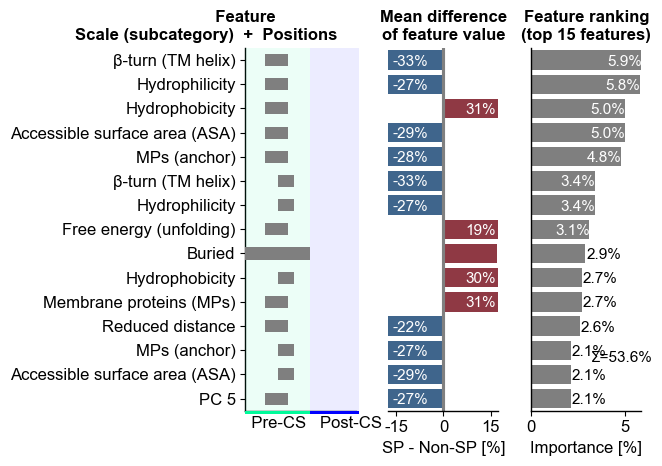

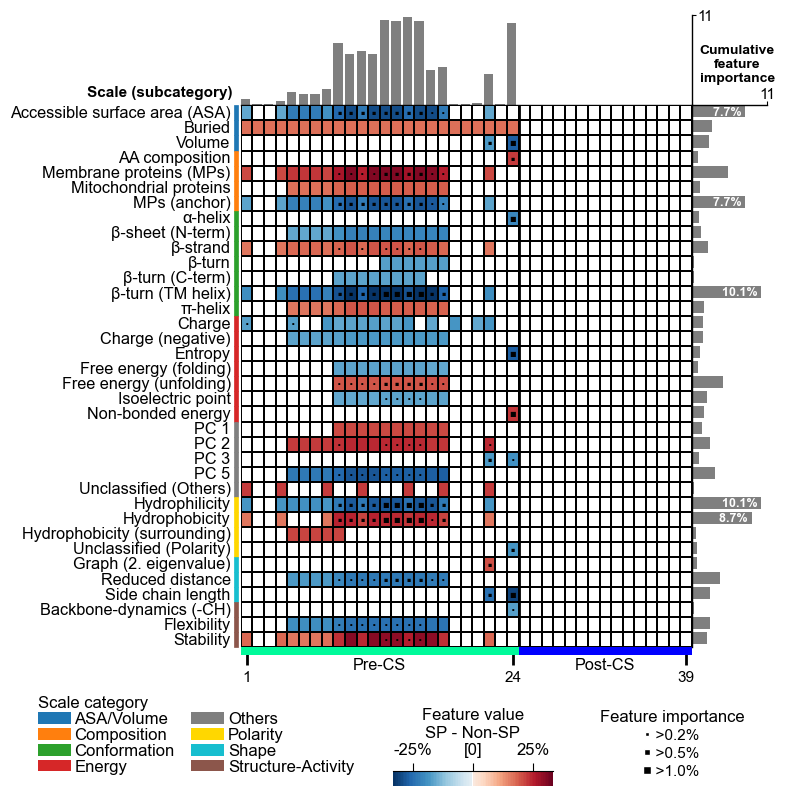

=== CPP interpretation: LIPO vs Non-SP ===
'Feature matrix' for 100 features and 5168 samples will be created.


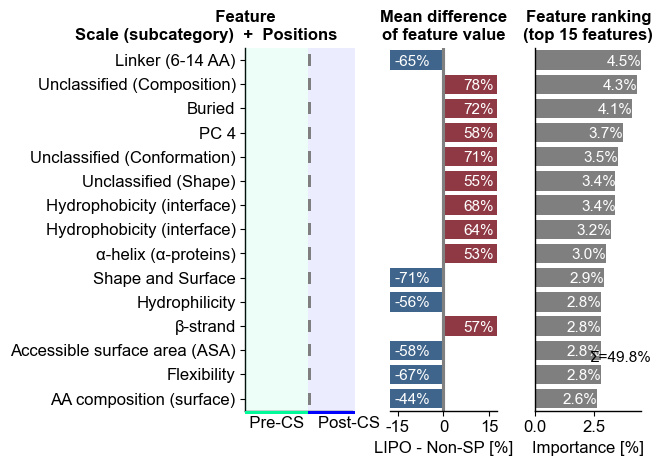

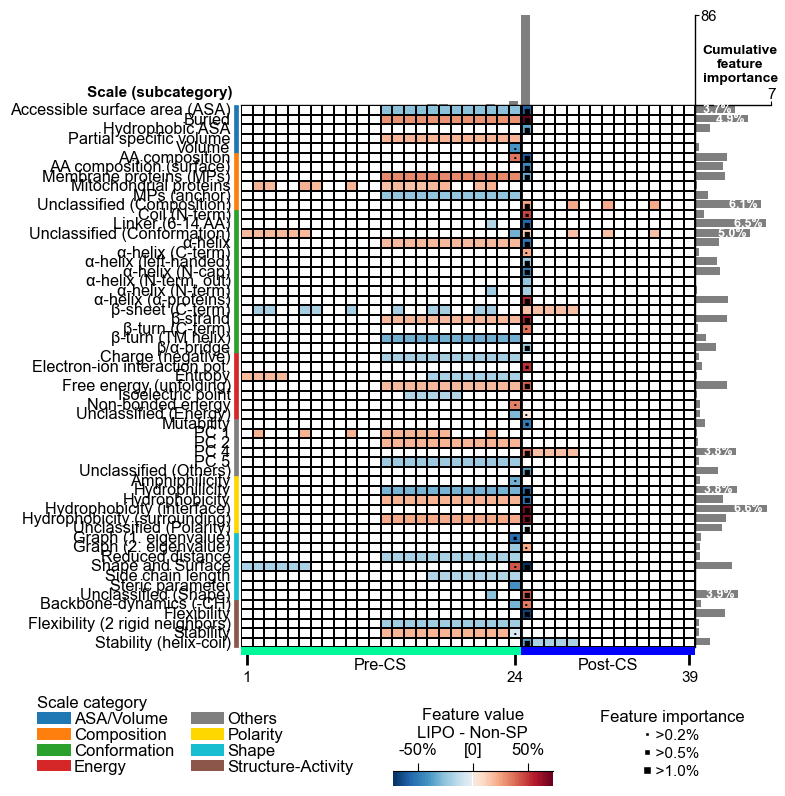

=== CPP interpretation: TAT vs Non-SP ===
'Feature matrix' for 100 features and 1752 samples will be created.


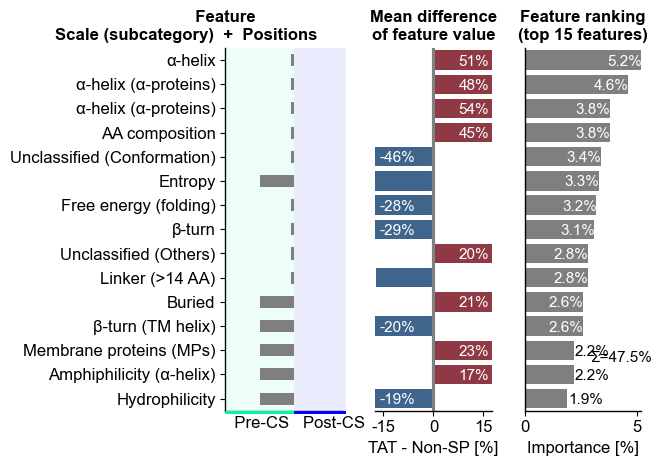

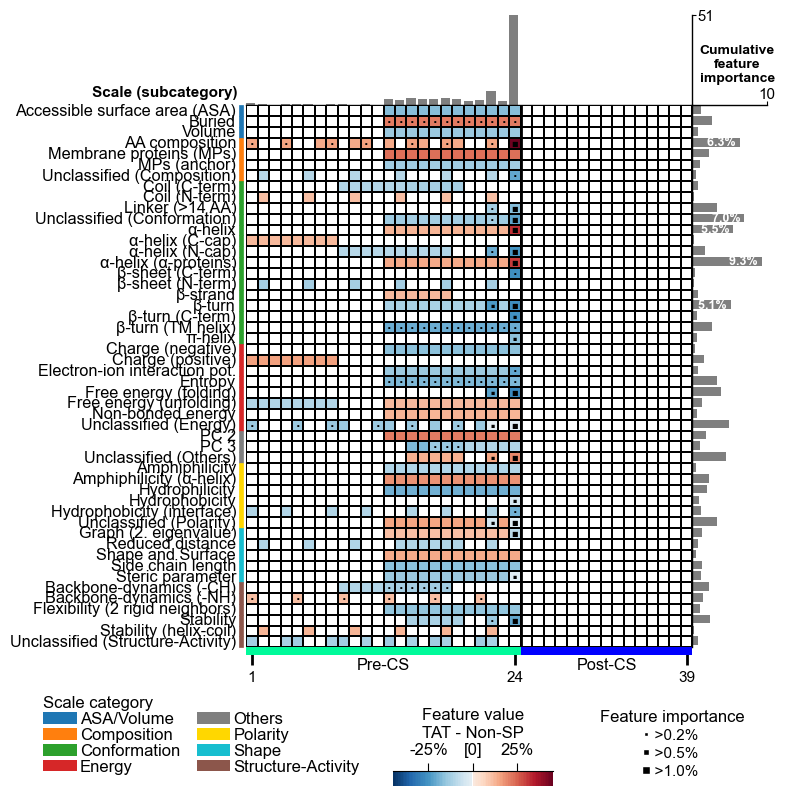

=== CPP interpretation: TATLIPO vs Non-SP ===
'Feature matrix' for 100 features and 290 samples will be created.


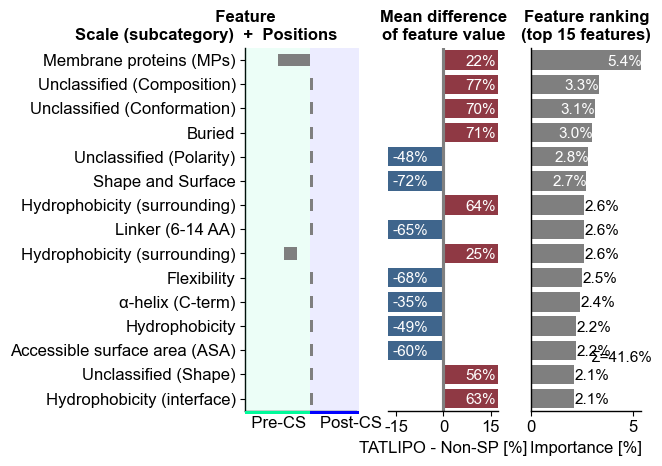

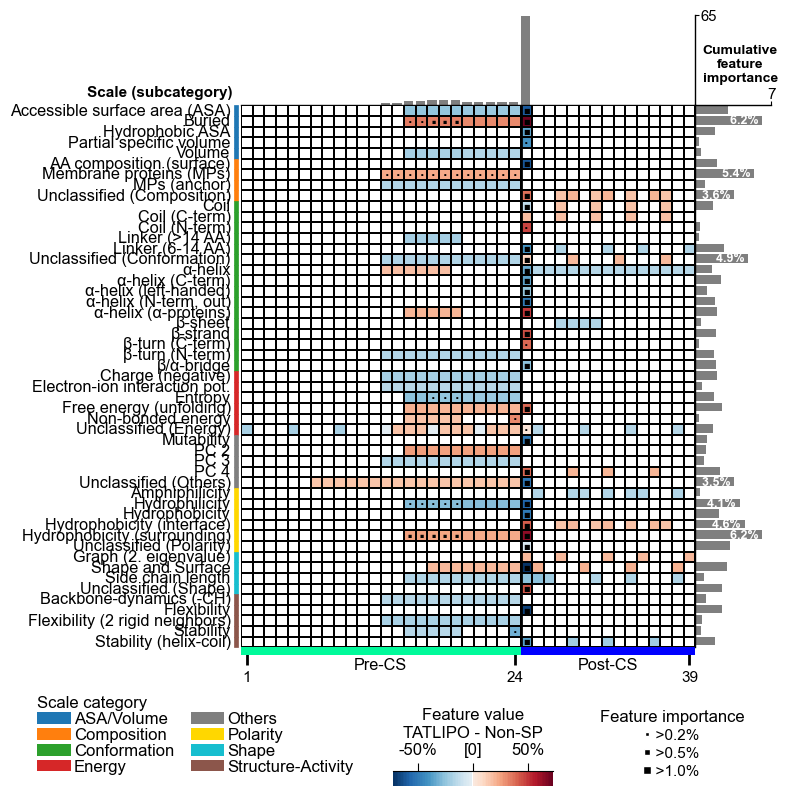

=== CPP interpretation: PILIN vs Non-SP ===
'Feature matrix' for 100 features and 589 samples will be created.


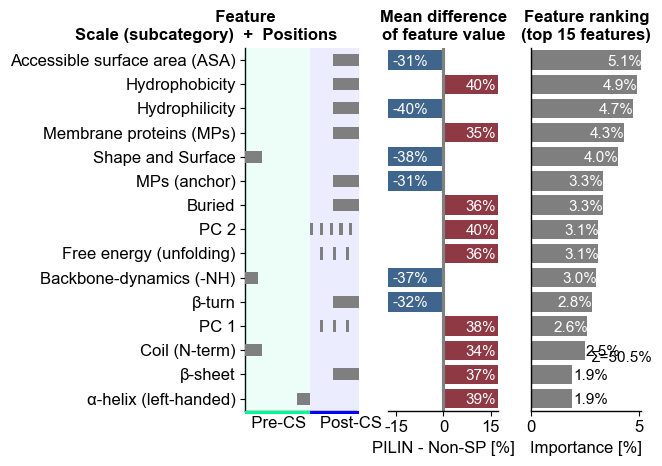

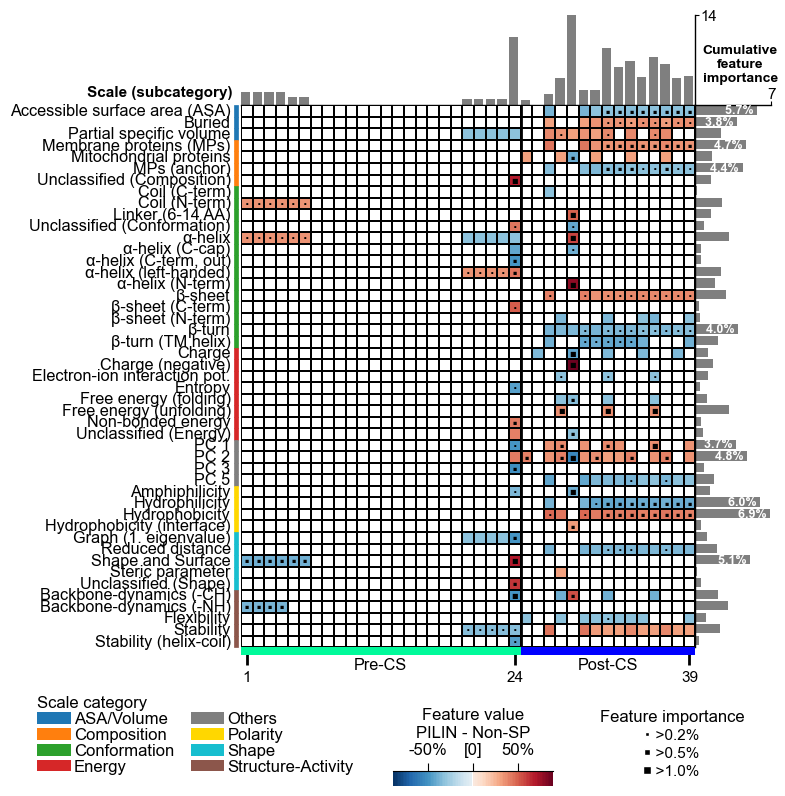

In [9]:
ut.options["name_tmd"] = "Pre-CS"
ut.options["name_jmd_c"] = "Post-CS"
ut.options["name_jmd_n"] = ""

cpp_plot = aa.CPPPlot(
    jmd_n_len=0,
    jmd_c_len=POST_CS_LEN,
)

for sp_type in SP_TYPES:
    print(f"=== CPP interpretation: {sp_type} vs Non-SP ===")

    train_pair = type_vs_nonsp_data[sp_type]["train"]
    df_feat_type = type_vs_nonsp_features[sp_type].copy()

    X_train = make_feature_matrix(train_pair, df_feat_type)
    y_train = train_pair["target_label"].values

    try:
        tm = aa.TreeModel()
        tm.fit(X_train, labels=y_train)
        df_feat_type = tm.add_feat_importance(
            df_feat=df_feat_type,
            drop=True,
        )
    except Exception as exc:
        print(f"Could not add feature importance for {sp_type}: {exc}")

    df_feat_type.to_csv(
        FEATURE_DIR / "metadata" / f"features_{sp_type}_vs_nonsp_with_importance.csv",
        index=False,
    )

    aa.plot_settings(
        short_ticks=True,
        weight_bold=False,
    )

    cpp_plot.ranking(
        df_feat=df_feat_type,
        name_test=sp_type,
        name_ref="Non-SP",
    )

    plt.tight_layout()
    plt.savefig(
        PLOT_DIR / f"cpp_ranking_{sp_type}_vs_nonsp.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    aa.plot_settings(
        font_scale=0.65,
        weight_bold=False,
    )

    cpp_plot.feature_map(
        df_feat=df_feat_type,
        tmd_len=PRE_CS_LEN_FOR_PLOTS,
        name_test=sp_type,
        name_ref="Non-SP",
    )

    plt.tight_layout()
    plt.savefig(
        PLOT_DIR / f"cpp_feature_map_{sp_type}_vs_nonsp.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


## 9. Save interpretation summary

In [10]:
summary = {
    "sp_types": SP_TYPES,
    "min_pre_cs_len": MIN_PRE_CS_LEN,
    "post_cs_len": POST_CS_LEN,
    "pre_cs_len_for_plots": PRE_CS_LEN_FOR_PLOTS,
    "max_cor": MAX_COR,
    "type_nonsp_ratios": TYPE_NONSP_RATIOS,
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "note": "Type-vs-Non-SP CPP interpretation. These analyses are for biological characterization, not the main SP type classification pipeline.",
}

summary_path = METRIC_DIR / "type_vs_nonsp_interpretation_summary.json"
with open(summary_path, "w") as file:
    json.dump(summary, file, indent=2)

print(f"Saved interpretation summary to: {summary_path}")
summary


Saved interpretation summary to: /Users/jun/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Desktop_Kang/Uni/Master 1/signal_peptide_cpp/results/metrics/type_vs_nonsp_interpretation_summary.json


{'sp_types': ['SP', 'LIPO', 'TAT', 'TATLIPO', 'PILIN'],
 'min_pre_cs_len': 5,
 'post_cs_len': 15,
 'pre_cs_len_for_plots': 24,
 'max_cor': 0.5,
 'type_nonsp_ratios': {'SP': 2,
  'LIPO': 3,
  'TAT': 5,
  'TATLIPO': 10,
  'PILIN': 10},
 'test_size': 0.2,
 'random_state': 42,
 'note': 'Type-vs-Non-SP CPP interpretation. These analyses are for biological characterization, not the main SP type classification pipeline.'}